# Exploratory Data Analysis

In [2]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")
df.shape, df["Class"].value_counts(), df["Class"].mean()

((284807, 31),
 Class
 0    284315
 1       492
 Name: count, dtype: int64,
 np.float64(0.001727485630620034))

## Imbalance Visualisation

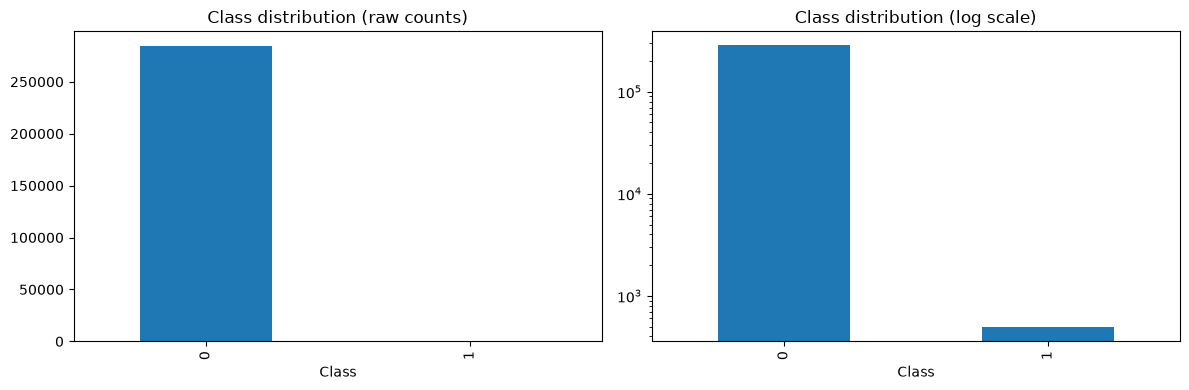

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Class"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Class distribution (raw counts)")

df["Class"].value_counts().plot(kind="bar", ax=axes[1], logy=True)
axes[1].set_title("Class distribution (log scale)")

plt.tight_layout()
plt.show()

## Amount per Class

In [4]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## Amount Distribution

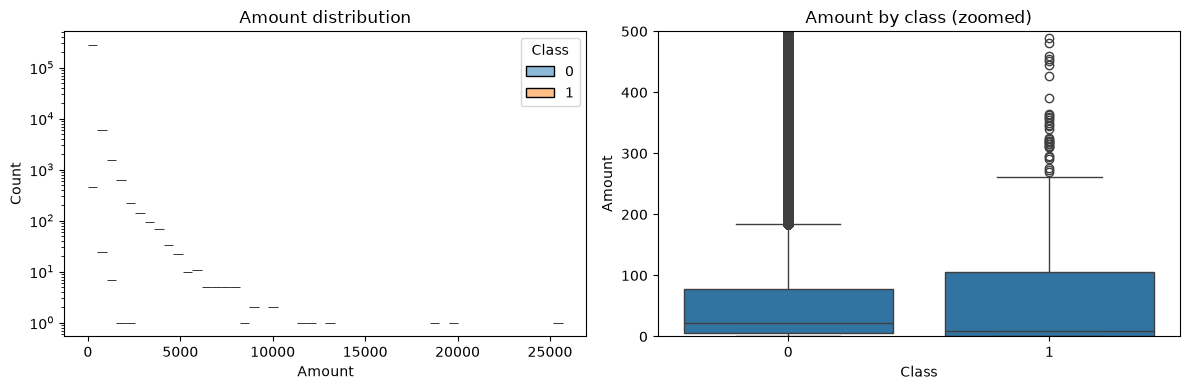

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="Amount", hue="Class", bins=50,
             log_scale=(False, True), ax=axes[0])
axes[0].set_title("Amount distribution")

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[1])
axes[1].set_ylim(0, 500)  # zoom, αλλιώς τα outliers "πλακώνουν" το plot
axes[1].set_title("Amount by class (zoomed)")

plt.tight_layout()
plt.show()

## Time

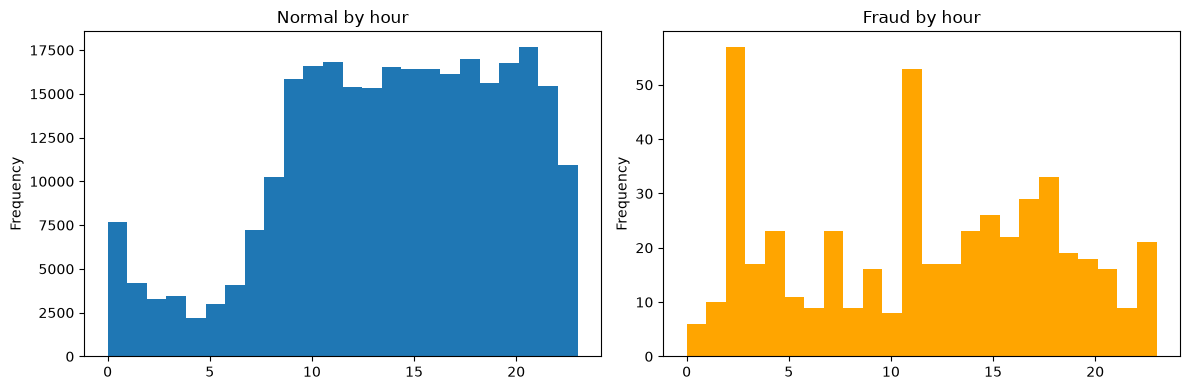

In [6]:
df["Hour"] = (df["Time"] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df["Class"] == 0]["Hour"].plot(kind="hist", bins=24, ax=axes[0], title="Normal by hour")
df[df["Class"] == 1]["Hour"].plot(kind="hist", bins=24, ax=axes[1], color="orange", title="Fraud by hour")

plt.tight_layout()
plt.show()

## EDA Findings

**1. Severe class imbalance.**
Only 492 of 284,807 transactions are fraudulent (0.17%). A model that always
predicts "not fraud" achieves 99.83% accuracy, so accuracy is meaningless
here — evaluation must focus on the fraud class (precision, recall, PR curve).

**2. Fraud amounts are not large.**
Fraudulent transactions have a *lower* median amount than normal ones
(€9.25 vs €22.00), and 25% of frauds are ≤ €1 — consistent with "card
testing", where a stolen card is first probed with a tiny charge. The mean
(€122 vs €88) is misleading in both classes due to right-skewed
distributions with extreme outliers (max €25,691).

**3. Frauds ignore the daily cycle.**
Normal transactions follow a clear human pattern: a deep dip between roughly
2–7 AM and a stable daytime plateau. Frauds show no such dip — their largest
spike occurs around 2 AM, when legitimate activity is at its minimum, so the
fraud *rate* at night is several times the overall 0.17%. Caveat: the dataset
covers only two days and 492 fraud cases, so hourly patterns are indicative,
not conclusive.

**Modeling implications:**
- Accuracy is uninformative → evaluate with precision/recall, F1, and the
  precision-recall curve (Average Precision).
- `Amount` is heavily right-skewed → apply a log transform (`log1p`).
- `Hour` (derived from `Time`) carries real signal → keep it as an
  engineered feature; drop the raw `Time` counter.
- Stratified train/test split is required to preserve the 0.17% fraud
  ratio in both sets.